Saving combined_sweep.csv to combined_sweep.csv
Loaded 64 rows  (32 baseline, 32 tiled)
 variant  B    N   d  latency_ms  throughput_k_tokens_per_sec
baseline  1  128  64      0.0494                      2593.26
   tiled  1  128  64      0.0446                      2866.87
baseline  1  128 128      0.0571                      2242.58
   tiled  1  128 128      0.0470                      2724.59
baseline  1  256  64      0.1659                      1543.30
   tiled  1  256  64      0.1475                      1735.54
baseline  1  256 128      0.2008                      1275.20
   tiled  1  256 128      0.1627                      1573.61
baseline  1  512  64      0.3920                      1305.99
   tiled  1  512  64      0.3239                      1580.86
baseline  1  512 128      0.5133                       997.46
   tiled  1  512 128      0.3776                      1356.06
baseline  1 1024  64      1.0152                      1008.63
   tiled  1 1024  64      0.7502            

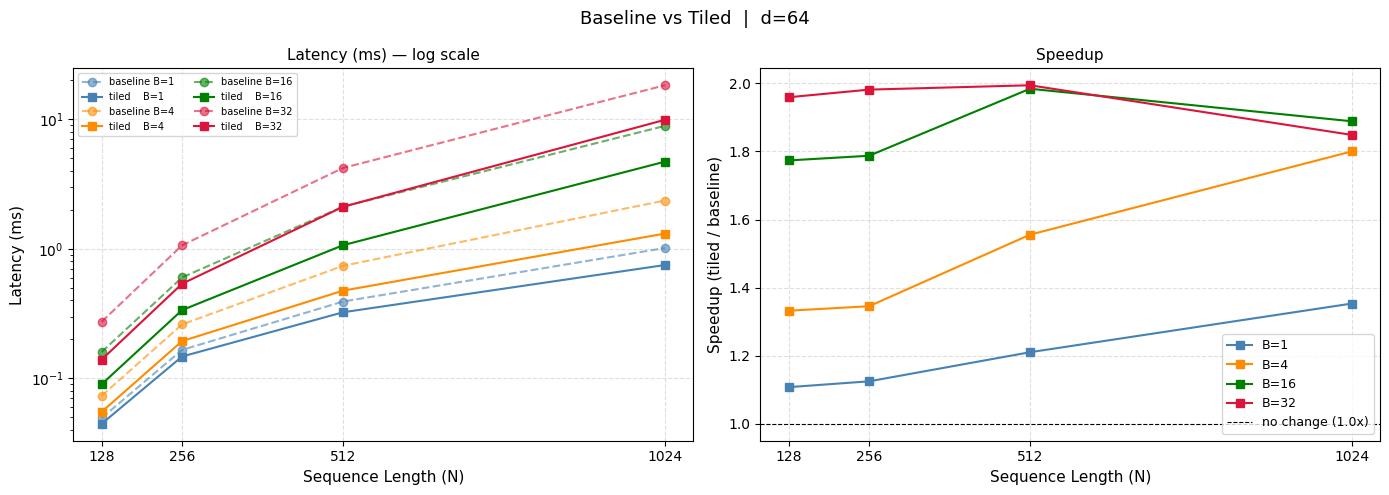

Saved: week3_comparison_d64.png


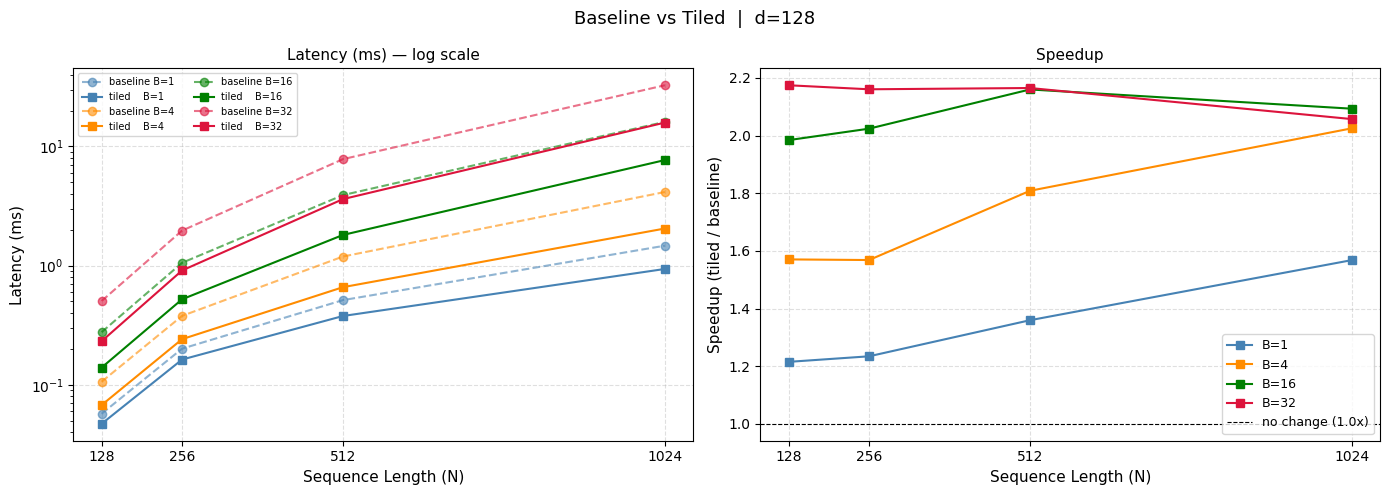

Saved: week3_comparison_d128.png


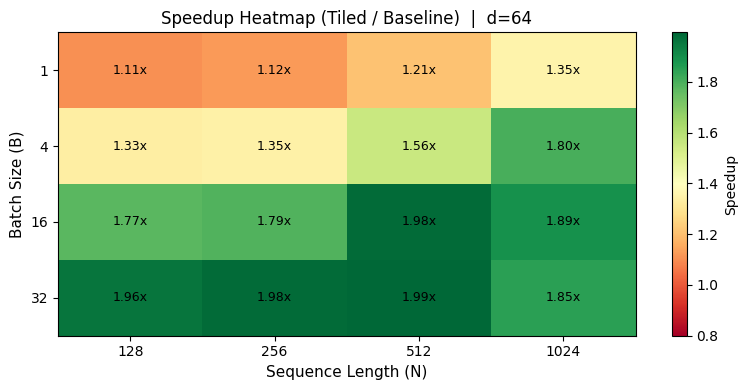

Saved: week3_speedup_heatmap_d64.png


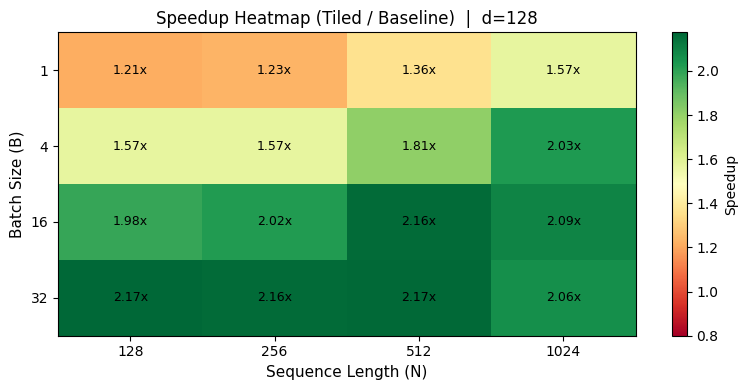

Saved: week3_speedup_heatmap_d128.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

All plots downloaded.


In [1]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  Week 3 — Baseline vs Tiled Comparison Analysis (Colab)         ║
# ║                                                                  ║
# ║  Upload combined_sweep.csv when prompted.                       ║
# ║  Produces 4 figures for the paper + speedup summary table.      ║
# ╚══════════════════════════════════════════════════════════════════╝

# ─────────────────────────────────────────────────────────────────
# Cell 1 — Upload and load CSV
# ─────────────────────────────────────────────────────────────────

from google.colab import files
import pandas as pd
import io

uploaded = files.upload()
fname = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[fname]))

baseline = df[df["variant"] == "baseline"].copy()
tiled    = df[df["variant"] == "tiled"].copy()

print(f"Loaded {len(df)} rows  ({len(baseline)} baseline, {len(tiled)} tiled)")
print(df.to_string(index=False))


# ─────────────────────────────────────────────────────────────────
# Cell 2 — Speedup table (primary result)
# ─────────────────────────────────────────────────────────────────

import numpy as np

merged = baseline.merge(tiled, on=["B","N","d"], suffixes=("_base","_tiled"))
merged["speedup"]       = merged["latency_ms_base"] / merged["latency_ms_tiled"]
merged["latency_delta"] = merged["latency_ms_base"] - merged["latency_ms_tiled"]

print("\n=== Speedup: Tiled vs Baseline ===")
print(f"{'B':>4} {'N':>6} {'d':>4} {'Base (ms)':>10} {'Tiled (ms)':>11} "
      f"{'Speedup':>9} {'Delta (ms)':>11}")
print("-" * 62)
for _, r in merged.sort_values(["d","B","N"]).iterrows():
    marker = " ◀" if r["speedup"] > 1.1 else (" ▼" if r["speedup"] < 0.95 else "")
    print(f"{int(r.B):>4} {int(r.N):>6} {int(r.d):>4} "
          f"{r.latency_ms_base:>10.3f} {r.latency_ms_tiled:>11.3f} "
          f"{r.speedup:>9.3f}x {r.latency_delta:>11.3f}{marker}")

print(f"\nOverall mean speedup: {merged['speedup'].mean():.3f}x")
print(f"Best speedup:         {merged['speedup'].max():.3f}x  "
      f"(B={int(merged.loc[merged.speedup.idxmax(),'B'])}, "
      f"N={int(merged.loc[merged.speedup.idxmax(),'N'])}, "
      f"d={int(merged.loc[merged.speedup.idxmax(),'d'])})")
print(f"Worst speedup:        {merged['speedup'].min():.3f}x  "
      f"(B={int(merged.loc[merged.speedup.idxmin(),'B'])}, "
      f"N={int(merged.loc[merged.speedup.idxmin(),'N'])}, "
      f"d={int(merged.loc[merged.speedup.idxmin(),'d'])})")


# ─────────────────────────────────────────────────────────────────
# Cell 3 — Latency comparison: Baseline vs Tiled across N
# ─────────────────────────────────────────────────────────────────

import matplotlib.pyplot as plt

for d_val in sorted(df["d"].unique()):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"Baseline vs Tiled  |  d={d_val}", fontsize=13)

    colors = {1: "steelblue", 4: "darkorange", 16: "green", 32: "crimson"}

    for B_val in sorted(df["B"].unique()):
        b_grp = baseline[(baseline["B"]==B_val) & (baseline["d"]==d_val)].sort_values("N")
        t_grp = tiled   [(tiled["B"]   ==B_val) & (tiled["d"]   ==d_val)].sort_values("N")
        c = colors[B_val]

        # Left: raw latency
        axes[0].plot(b_grp["N"], b_grp["latency_ms"],
                     marker="o", linestyle="--", color=c, alpha=0.6,
                     label=f"baseline B={B_val}")
        axes[0].plot(t_grp["N"], t_grp["latency_ms"],
                     marker="s", linestyle="-",  color=c,
                     label=f"tiled    B={B_val}")

        # Right: speedup
        sp_grp = merged[(merged["B"]==B_val) & (merged["d"]==d_val)].sort_values("N")
        axes[1].plot(sp_grp["N"], sp_grp["speedup"],
                     marker="s", color=c, label=f"B={B_val}")

    axes[0].set_xlabel("Sequence Length (N)", fontsize=11)
    axes[0].set_ylabel("Latency (ms)", fontsize=11)
    axes[0].set_title("Latency (ms) — log scale", fontsize=11)
    axes[0].set_yscale("log")
    axes[0].set_xticks(sorted(df["N"].unique()))
    axes[0].legend(fontsize=7, ncol=2)
    axes[0].grid(True, linestyle="--", alpha=0.4)

    axes[1].axhline(y=1.0, color="black", linestyle="--", linewidth=0.8,
                    label="no change (1.0x)")
    axes[1].set_xlabel("Sequence Length (N)", fontsize=11)
    axes[1].set_ylabel("Speedup (tiled / baseline)", fontsize=11)
    axes[1].set_title("Speedup", fontsize=11)
    axes[1].set_xticks(sorted(df["N"].unique()))
    axes[1].legend(fontsize=9)
    axes[1].grid(True, linestyle="--", alpha=0.4)

    plt.tight_layout()
    out_name = f"week3_comparison_d{d_val}.png"
    plt.savefig(out_name, dpi=150)
    plt.show()
    print(f"Saved: {out_name}")


# ─────────────────────────────────────────────────────────────────
# Cell 4 — Speedup heatmap (B × N)
# ─────────────────────────────────────────────────────────────────

for d_val in sorted(merged["d"].unique()):
    sub = merged[merged["d"] == d_val]
    pivot = sub.pivot(index="B", columns="N", values="speedup")

    fig, ax = plt.subplots(figsize=(8, 4))

    # diverging colormap: red < 1, white = 1, green > 1
    vmin = min(0.8, pivot.values.min())
    vmax = max(1.2, pivot.values.max())
    im = ax.imshow(pivot.values, aspect="auto", cmap="RdYlGn",
                   vmin=vmin, vmax=vmax)

    ax.set_xticks(range(len(pivot.columns))); ax.set_xticklabels(pivot.columns)
    ax.set_yticks(range(len(pivot.index)));   ax.set_yticklabels(pivot.index)
    ax.set_xlabel("Sequence Length (N)", fontsize=11)
    ax.set_ylabel("Batch Size (B)", fontsize=11)
    ax.set_title(f"Speedup Heatmap (Tiled / Baseline)  |  d={d_val}", fontsize=12)

    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            v = pivot.values[i, j]
            ax.text(j, i, f"{v:.2f}x", ha="center", va="center", fontsize=9,
                    color="black")

    plt.colorbar(im, ax=ax, label="Speedup")
    plt.tight_layout()
    out_name = f"week3_speedup_heatmap_d{d_val}.png"
    plt.savefig(out_name, dpi=150)
    plt.show()
    print(f"Saved: {out_name}")


# ─────────────────────────────────────────────────────────────────
# Cell 5 — Download all plots
# ─────────────────────────────────────────────────────────────────

import glob
for f in glob.glob("week3_*.png"):
    files.download(f)
print("All plots downloaded.")